In [98]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [99]:
df = pd.read_csv("../data/raw_steam_data.csv")

print("✅ Data ready for processing. Let's start the transformation.")
df.head(10)

✅ Data ready for processing. Let's start the transformation.


,Title,Price,Review_Summary
0,Counter-Strike 2,Free,"Very Positive 86% of the 2,508,216 user review..."
1,Crimson Desert,"Mex$ 1,299.00","Very Positive 83% of the 29,891 user reviews f..."
2,Apex Legends™,Free,"Mostly Positive 76% of the 438,048 user review..."
3,Marvel Rivals,Free,"Mostly Positive 78% of the 273,104 user review..."
4,Slay the Spire 2,Mex$ 290.00,"Overwhelmingly Positive 95% of the 35,636 user..."
5,Warframe,Free,"Very Positive 91% of the 289,295 user reviews ..."
6,Steam Deck,TBA,No Reviews
7,Gray Zone Warfare,Mex$ 381.83,"Mostly Positive 71% of the 40,526 user reviews..."
8,PUBG: BATTLEGROUNDS,Free,"Mixed 66% of the 443,263 user reviews for this..."
9,ARC Raiders,Mex$ 607.20,"Very Positive 86% of the 180,543 user reviews ..."


In [100]:
df.columns = ['title', 'price', 'review_summary']

In [101]:
df['price'] = df['price'].str.replace('Free', '0', case=False)

In [102]:
df['price'] = df['price'].str.replace('TBA', 'Nan', case=False)


In [103]:
df['price'] = df['price'].str.replace(r'[^\d.]', '', regex=True)

In [104]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

print(df['price'].dtype)

float64


In [105]:
pattern = r'^(.*?) (\d+)% of the ([\d,]+) user reviews'

new_cols = df['review_summary'].str.extract(pattern)
new_cols.columns = ['sentiment', 'positive_percent', 'review_volume']

df = pd.concat([df, new_cols], axis=1)

In [106]:
df['review_volume'] = df['review_volume'].str.replace(',', '', regex=False)
df['review_volume'] = pd.to_numeric(df['review_volume'], errors='coerce')
df['positive_percent'] = pd.to_numeric(df['positive_percent'], errors='coerce')
df.head()

,title,price,review_summary,sentiment,positive_percent,review_volume
0,Counter-Strike 2,0.0,"Very Positive 86% of the 2,508,216 user review...",Very Positive,86.0,2508216.0
1,Crimson Desert,1299.0,"Very Positive 83% of the 29,891 user reviews f...",Very Positive,83.0,29891.0
2,Apex Legends™,0.0,"Mostly Positive 76% of the 438,048 user review...",Mostly Positive,76.0,438048.0
3,Marvel Rivals,0.0,"Mostly Positive 78% of the 273,104 user review...",Mostly Positive,78.0,273104.0
4,Slay the Spire 2,290.0,"Overwhelmingly Positive 95% of the 35,636 user...",Overwhelmingly Positive,95.0,35636.0


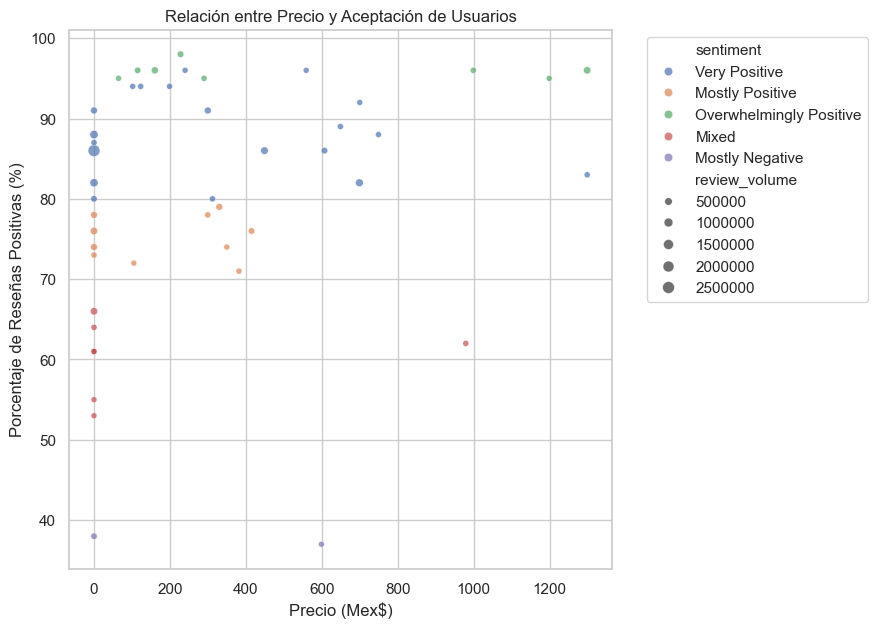

In [107]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(7, 7))
sns.scatterplot(data=df, x='price', y='positive_percent', size='review_volume', hue='sentiment', alpha=0.7)

plt.title('Relación entre Precio y Aceptación de Usuarios')
plt.xlabel('Precio (Mex$)')
plt.ylabel('Porcentaje de Reseñas Positivas (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

## **Exploratory Data Analysis Summary:**

Initial findings reveal a high density of titles priced between 0 and 400 MXN, where user satisfaction consistently peaks between 90% and 100%. This suggests that mid-to-low tier pricing often aligns best with user expectations. Conversely, the Free-to-Play segment exhibits the highest volatility in sentiment, spanning a wide range of approval ratings. Furthermore, the scarcity of titles priced above 800 MXN indicates a niche high-end market with a more stable, yet smaller, consumer base.

Pearson Correlation Matrix
                     price  positive_percent  review_volume
price             1.000000          0.259845      -0.160322
positive_percent  0.259845          1.000000       0.122098
review_volume    -0.160322          0.122098       1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

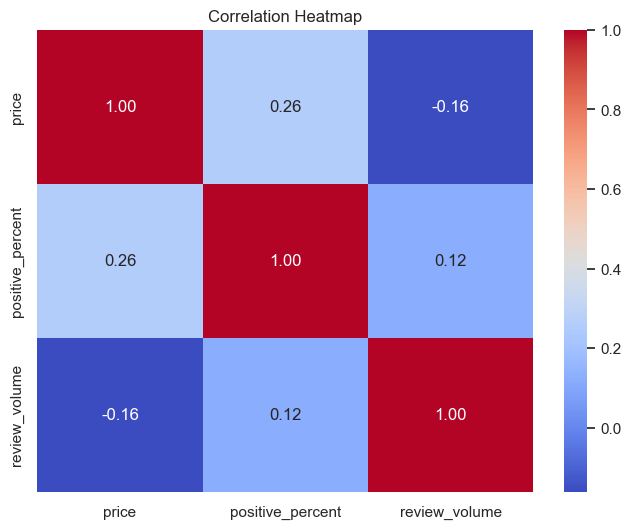

In [108]:
numeric_cols = df[['price', 'positive_percent', 'review_volume']]
correlation_matrix = numeric_cols.corr()

print("Pearson Correlation Matrix")
print(correlation_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")

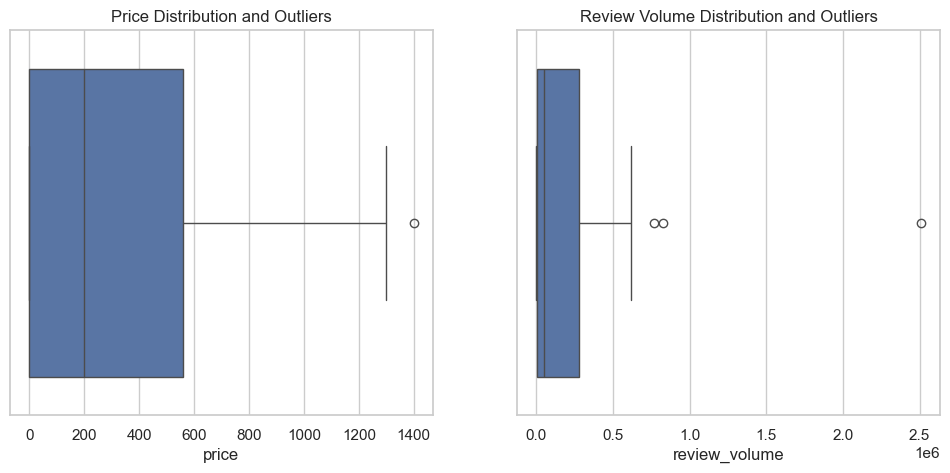

In [109]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['price'])
plt.title('Price Distribution and Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['review_volume'])
plt.title('Review Volume Distribution and Outliers')

plt.show()

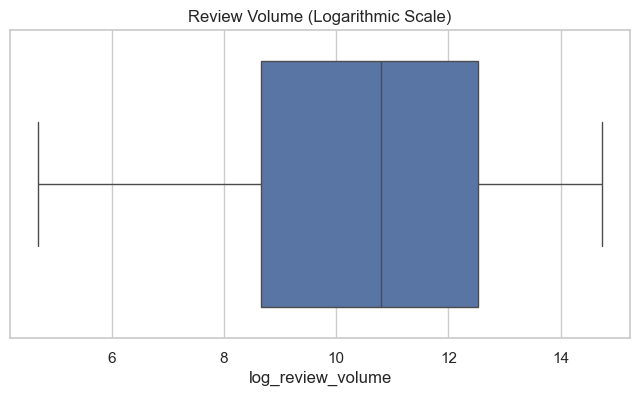

In [110]:
df['log_review_volume'] = np.log1p(df['review_volume'])

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['log_review_volume'])
plt.title('Review Volume (Logarithmic Scale)')
plt.show()

In [111]:
print(df[['price', 'positive_percent', 'log_review_volume']].corr())

                      price  positive_percent  log_review_volume
price              1.000000          0.259845          -0.117968
positive_percent   0.259845          1.000000           0.132419
log_review_volume -0.117968          0.132419           1.000000


In [112]:
cheap = df[df['price'] < 200 ]['positive_percent'].dropna()
expensive = df[df['price'] > 600]['positive_percent'].dropna()

t_stat, p_val = stats.ttest_ind(cheap, expensive)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("✅ Insight: There is a significant difference in satisfaction based on price.")
else:
    print("❌ Insight: There is no statistical evidence that price affects satisfaction.")

T-statistic: -1.8827
P-value: 0.0686
❌ Insight: There is no statistical evidence that price affects satisfaction.


**Statistical Note:**
While the T-test yielded a p-value of 0.068, which is slightly above the standard 0.05 threshold, the results suggest a potential trend regarding price and satisfaction. The current lack of significance is likely attributed to the limited sample size of high-end titles ($n=11$). Expanding the dataset would be necessary to confirm if this is a genuine market trend or merely stochastic noise.

## 📊 EDA Executive SummaryPrice vs. Satisfaction: 
Weak positive correlation ($r \approx 0.26$). Price is not a primary driver of player approval.Volume Distribution: Highly skewed with significant outliers (Blockbusters). Most games have low engagement.Feature Engineering: Applied Logarithmic Transformation ($np.log1p$) to review_volume to normalize the distribution and mitigate outlier impact for future modeling.Market Insight: The "Sweet Spot" for high satisfaction ($90\%+$) is concentrated in the 0-400 MXN range.

# 🤖 Phase 2: Machine Learning & Predictive Modeling
---

In [113]:
X = df[['price', 'positive_percent']]
y = df['log_review_volume']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Datos totales: {len(df)}")
print(f"Entrenando con: {len(X_train)} juegos")
print(f"Probando con: {len(X_test)} juegos")

Datos totales: 50
Entrenando con: 40 juegos
Probando con: 10 juegos


In [114]:
features_list = ['price', 'positive_percent', 'log_review_volume']
df_ml = df[features_list].dropna()

X = df_ml[['price', 'positive_percent']]
y = df_ml['log_review_volume']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print("✅ Model Training Successful!")
print(f"R-squared (Accuracy): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

✅ Model Training Successful!
R-squared (Accuracy): -0.4103
Mean Squared Error (MSE): 8.6266


In [115]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)

print("🌲 Random Forest Training Successful!")
print(f"New R-squared: {rf_r2:.4f}")
print(f"New MSE: {rf_mse:.4f}")

🌲 Random Forest Training Successful!
New R-squared: -0.2560
New MSE: 7.6824


### ⚠️ Model Performance Analysis
The results show a **negative R-squared** (-0.25), which means the model is not 
accurate yet. This happened for two main reasons:

1. **Small Dataset:** We only have 50 games. Machine Learning usually needs 
hundreds or thousands of rows to learn correctly.
2. **Hidden Factors:** Success on Steam is not only about **Price** or **Rating**. 
Other factors like "Game Genre," "Marketing," or "Release Date" are 
important but are not in our current data.

**Conclusion:** A simple model cannot predict success with this limited 
information. For a better model, we need more data and more features.

In [124]:
columns_to_export = ['title', 'price', 'positive_percent', 'log_review_volume']

df_tableau = df[columns_to_export].dropna().copy()

df_tableau.to_csv('../data/steam_games_cleaned_for_tableau.csv', index=False)

print(f"✅ CSV updated. It now has {len(df_tableau)} rows and the columns: {df_tableau.columns.tolist()}")

✅ CSV updated. It now has 48 rows and the columns: ['title', 'price', 'positive_percent', 'log_review_volume']
